# Notebook 3 — Model Training

Models trained and compared:
1. Logistic Regression (baseline)
2. Random Forest
3. XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

%matplotlib inline

## 1. Load Processed Data

In [2]:
# Load the training and test datasets that we prepared in Notebook 2
# train_resampled.csv: Training data with balanced classes (equal fraud/legitimate)
# test.csv: Test data with original class distribution (for realistic evaluation)
train = pd.read_csv('../data/processed/train_resampled.csv')
test  = pd.read_csv('../data/processed/test.csv')

# Separate features (X) from the target variable (y)
# X = input features the model uses to make predictions
# y = target variable (Class: 0=legitimate, 1=fraud)

# Training data:
X_train = train.drop(columns=['Class'])  # All columns except 'Class'
y_train = train['Class']                 # Just the 'Class' column

# Test data:
X_test  = test.drop(columns=['Class'])
y_test  = test['Class']

# Print the shapes to see how much data we have
# Shape = (number of rows, number of columns)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (454902, 30) | Test: (56962, 30)


## 2. Train Models

In [3]:
# Define the three models we want to train
# Each model is created with specific settings (hyperparameters)

models = {
    # Model 1: Logistic Regression (simple baseline model)
    # max_iter=1000: allow up to 1000 iterations to find the best solution
    # random_state=42: ensures reproducible results
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    
    # Model 2: Random Forest (ensemble of decision trees)
    # n_estimators=100: use 100 decision trees
    # n_jobs=-1: use all available CPU cores for faster training
    # random_state=42: ensures reproducible results
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    
    # Model 3: XGBoost (gradient boosting model)
    # n_estimators=100: use 100 boosting rounds
    # eval_metric='logloss': use log loss as the evaluation metric
    # verbosity=0: don't print training progress (keeps output clean)
    # random_state=42: ensures reproducible results
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
}

# Create a folder to save our trained models
# exist_ok=True means "don't error if folder already exists"
os.makedirs('../reports/models', exist_ok=True)

# Dictionary to store results for each model
results = {}

# Train each model and evaluate it
for name, model in models.items():
    print(f'Training {name}...')
    
    # Train the model on our training data
    # The model learns patterns from X_train to predict y_train
    model.fit(X_train, y_train)
    
    # Make predictions on the test data
    # y_pred: hard predictions (0 or 1)
    y_pred  = model.predict(X_test)
    
    # y_proba: probability predictions (0.0 to 1.0)
    # [:, 1] means "take the second column" (probability of fraud)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate AUC-ROC score (Area Under the ROC Curve)
    # This measures how well the model can distinguish fraud from legitimate
    # Score ranges from 0.5 (random guessing) to 1.0 (perfect)
    auc = roc_auc_score(y_test, y_proba)
    
    # Store all results for this model
    results[name] = {'model': model, 'y_pred': y_pred, 'y_proba': y_proba, 'auc': auc}
    
    # Print the AUC score
    print(f'  AUC-ROC: {auc:.4f}')
    
    # Save the trained model to a file so we can use it later
    # We convert spaces to underscores and make lowercase for the filename
    # 'wb' means "write binary" mode
    with open(f'../reports/models/{name.replace(" ", "_").lower()}.pkl', 'wb') as f:
        pickle.dump(model, f)

print('\nAll models trained and saved.')

Training Logistic Regression...
  AUC-ROC: 0.9698
Training Random Forest...
  AUC-ROC: 0.9841
Training XGBoost...
  AUC-ROC: 0.9792

All models trained and saved.


## 3. Classification Reports

In [4]:
# Key metrics explained:
#   Precision: Of all transactions we flagged as fraud, what % were actually fraud?
#   Recall: Of all actual frauds, what % did we catch?
#   F1-Score: Harmonic mean of precision and recall (balance between both)
#   Support: Number of transactions in each class

for name, res in results.items():
    print(f'\n{"="*60}')
    print(f'{name}')
    print(f'{"="*60}')
    
    # Generate and print the classification report
    # target_names: give readable names to the classes instead of 0 and 1
    print(classification_report(y_test, res['y_pred'], 
                                target_names=['Legitimate', 'Fraud']))


=== Logistic Regression ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


=== Random Forest ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.84      0.81      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962


=== XGBoost ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weigh

## 4. ROC Curves

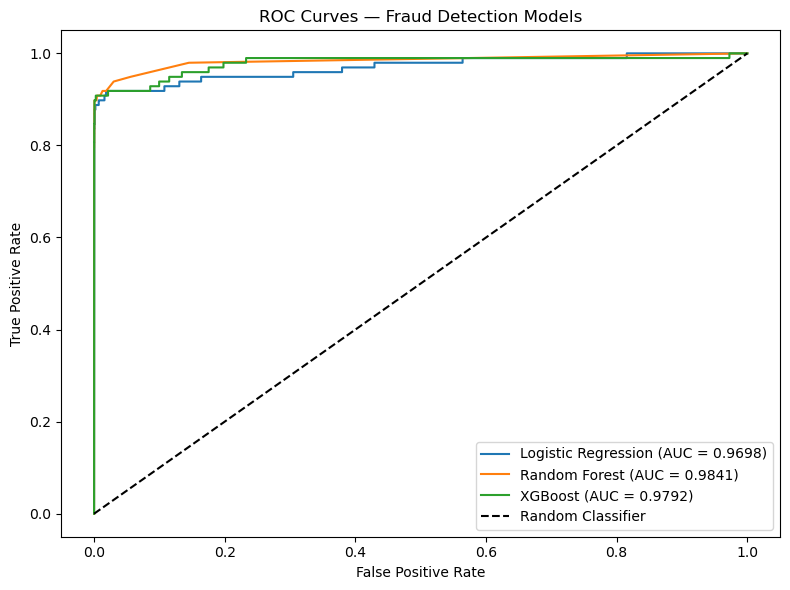

In [5]:
# A curve closer to the top-left corner is better
# The diagonal line represents random guessing

# Import the function to calculate ROC curve points
from sklearn.metrics import roc_curve

# Create a new figure for the plot
plt.figure(figsize=(8, 6))

# Plot a ROC curve for each model
for name, res in results.items():
    # Calculate the ROC curve
    # fpr: False Positive Rate at different thresholds
    # tpr: True Positive Rate at different thresholds
    # _: thresholds (we don't need these, so we ignore them with _)
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    
    # Plot the curve for this model
    # The label includes the model name and its AUC score
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.4f})")

# Add the diagonal line representing random guessing
# 'k--' means black ('k') dashed ('--') line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Add axis labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Fraud Detection Models')

# Show the legend in the lower right corner
plt.legend(loc='lower right')

# Adjust spacing
plt.tight_layout()

# Save the chart
plt.savefig('../reports/roc_curves.png', dpi=150)

# Display the chart
plt.show()


**Next step:** Notebook 04 — Evaluation & Business Interpretation